# IPEADATA - Instituto de Pesquisa Econômica Aplicada

Indicadores de risco-país, preço do petróleo, produção siderúrgica, exportações de minerais e indicadores industriais.

**Fontes:** JP Morgan, EIA, IMF/IFS, IABr, FUNCEX, CNI - via IPEADATA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json, os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

DATA_DIR = '../data/ipeadata'
CUTOFF = '2021-03-01'

In [2]:
daily = pd.read_csv(os.path.join(DATA_DIR, 'daily.csv'), index_col=0, parse_dates=True)
monthly = pd.read_csv(os.path.join(DATA_DIR, 'monthly.csv'), index_col=0, parse_dates=True)

daily = daily[daily.index >= CUTOFF]
monthly = monthly[monthly.index >= CUTOFF]

print(f'Diário: {daily.shape} | {daily.index.min().date()} a {daily.index.max().date()}')
print(f'Mensal: {monthly.shape} | {monthly.index.min().date()} a {monthly.index.max().date()}')
print(f'Colunas diárias: {list(daily.columns)}')
print(f'Colunas mensais: {list(monthly.columns)}')

Daily: (1302, 2) | 2021-03-01 to 2026-03-23
Monthly: (60, 11) | 2021-03-01 to 2026-02-01
Daily cols: ['embi_brasil', 'preco_petroleo_brent']
Monthly cols: ['preco_petroleo_mensal', 'producao_aco_bruto', 'producao_ferro_gusa', 'producao_laminados', 'export_minerais_metalicos_fob', 'export_minerais_metalicos_quantum', 'export_minerais_metalicos_preco', 'export_metalurgia_fob', 'utilizacao_capacidade_industrial', 'emprego_industrial', 'faturamento_real_industrial']


## EMBI+ Risco-País+ Brasil (Risco-País)
Índice de títulos de mercados emergentes - mede o spread de risco dos títulos brasileiros.

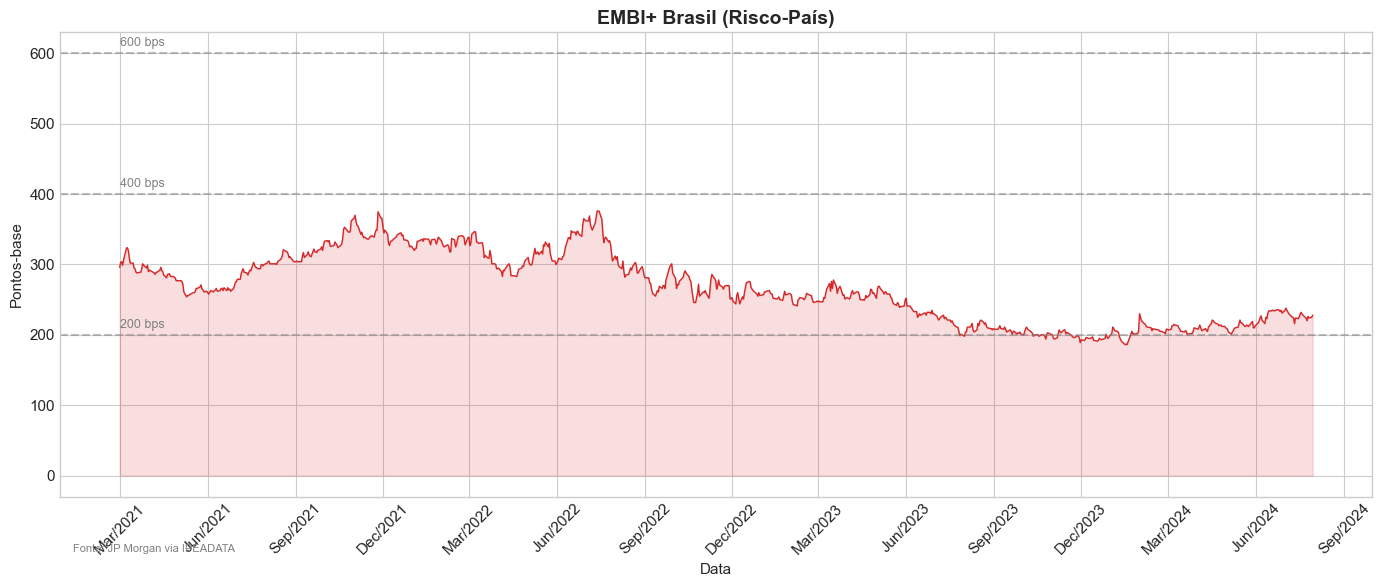

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

s = daily['embi_brasil'].dropna()
ax.plot(s.index, s, color='#d62728', linewidth=1)
ax.fill_between(s.index, s, alpha=0.15, color='#d62728')

for level, label in [(200, '200 bps'), (400, '400 bps'), (600, '600 bps')]:
    ax.axhline(y=level, color='gray', linestyle='--', alpha=0.5)
    ax.annotate(label, xy=(s.index[0], level + 10), fontsize=9, color='gray')

ax.set_title('EMBI+ Brasil (Risco-País)', fontsize=14, fontweight='bold')
ax.set_ylabel('Pontos-base')
ax.set_xlabel('Data')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: JP Morgan via IPEADATA', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Preço do Petróleo Brent (Diário)
Petróleo cru, Brent, preço spot (FOB).

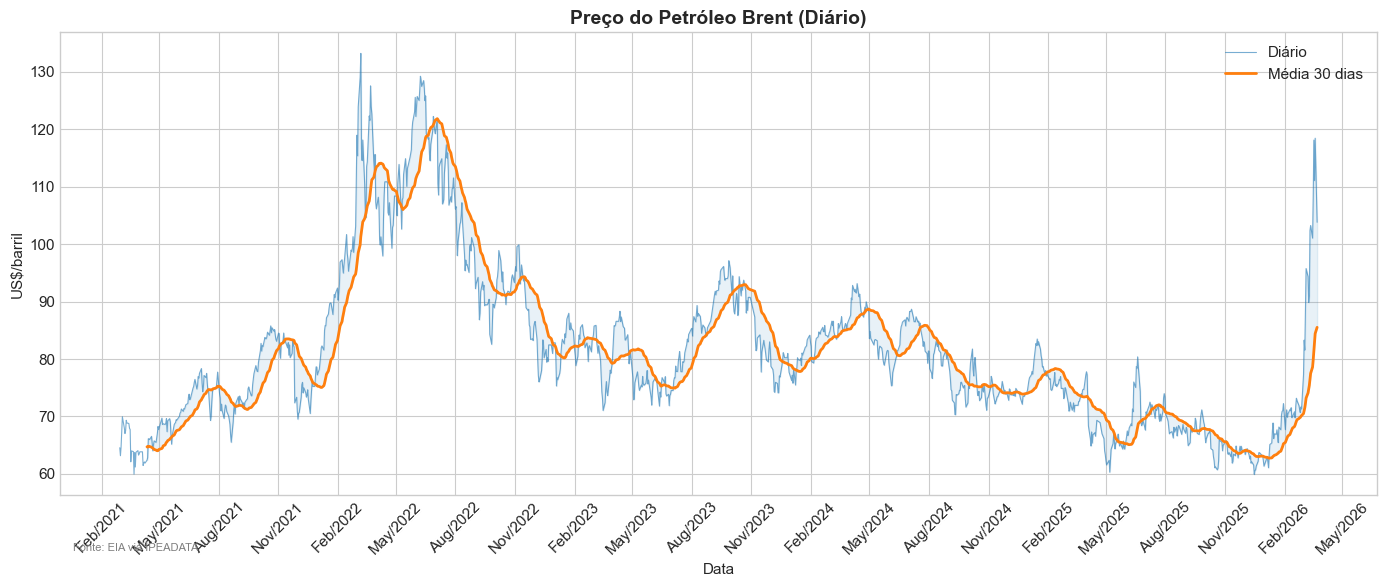

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

s = daily['preco_petroleo_brent'].dropna()
rolling30 = s.rolling(30).mean()
ax.plot(s.index, s, color='#1f77b4', linewidth=0.8, alpha=0.6, label='Diário')
ax.plot(s.index, rolling30, color='#ff7f0e', linewidth=2, label='Média 30 dias')
ax.fill_between(s.index, s, rolling30, alpha=0.1, color='#1f77b4')

ax.set_title('Preço do Petróleo Brent (Diário)', fontsize=14, fontweight='bold')
ax.set_ylabel('US$/barril')
ax.set_xlabel('Data')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: EIA via IPEADATA', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Preço do Petróleo - Cotação Internacional (Mensal)
Média mensal da cotação internacional do petróleo.

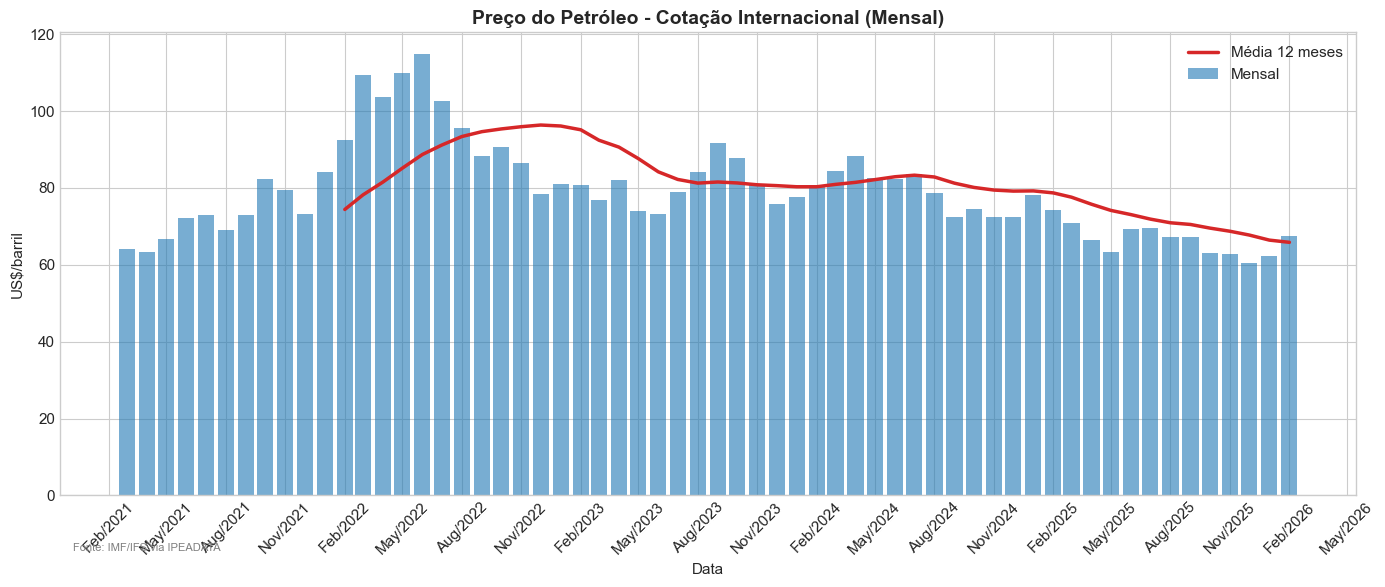

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

s = monthly['preco_petroleo_mensal'].dropna()
rolling12 = s.rolling(12).mean()
ax.bar(s.index, s, width=25, color='#1f77b4', alpha=0.6, label='Mensal')
ax.plot(s.index, rolling12, color='#d62728', linewidth=2.5, label='Média 12 meses')

ax.set_title('Preço do Petróleo - Cotação Internacional (Mensal)', fontsize=14, fontweight='bold')
ax.set_ylabel('US$/barril')
ax.set_xlabel('Data')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: IMF/IFS via IPEADATA', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Produção Siderúrgica Mensal
Aço bruto, ferro-gusa e laminados - produção mensal em mil toneladas.

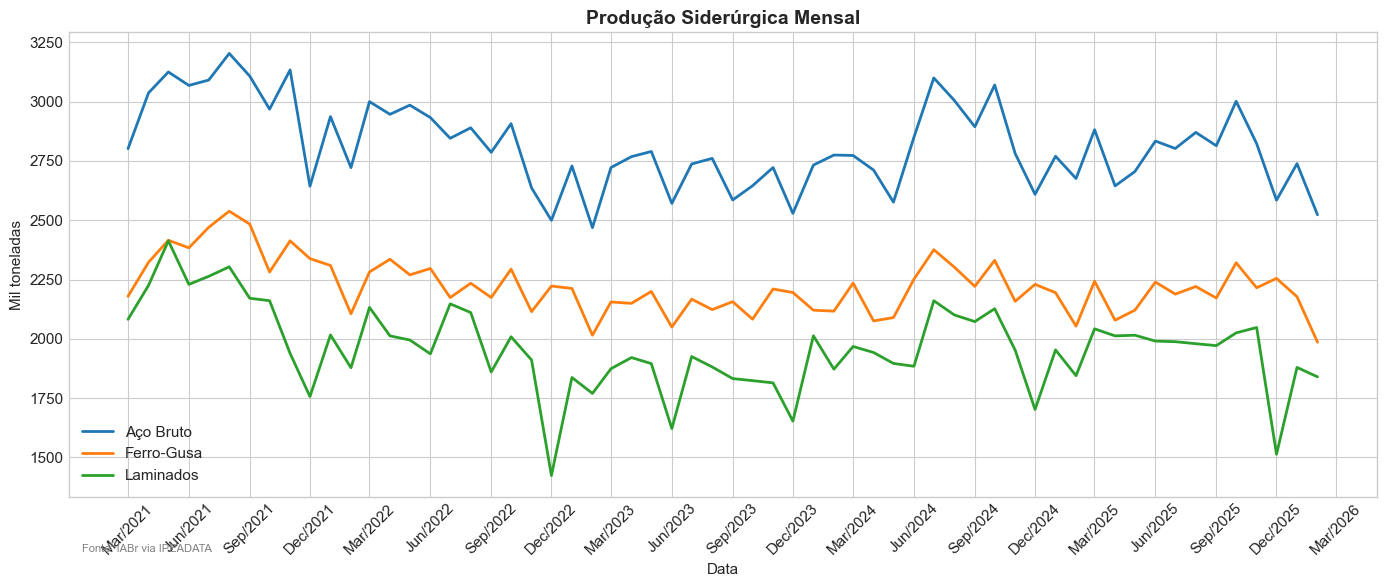

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

for col, label, color in [
    ('producao_aco_bruto', 'Aço Bruto', '#1f77b4'),
    ('producao_ferro_gusa', 'Ferro-Gusa', '#ff7f0e'),
    ('producao_laminados', 'Laminados', '#2ca02c'),
]:
    s = monthly[col].dropna()
    ax.plot(s.index, s, label=label, color=color, linewidth=2)

ax.set_title('Produção Siderúrgica Mensal', fontsize=14, fontweight='bold')
ax.set_ylabel('Mil toneladas')
ax.set_xlabel('Data')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: IABr via IPEADATA', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Exportações - Minerais Metálicos e Metalurgia
Valor FOB, índices de quantum e preço das exportações de minerais metálicos.

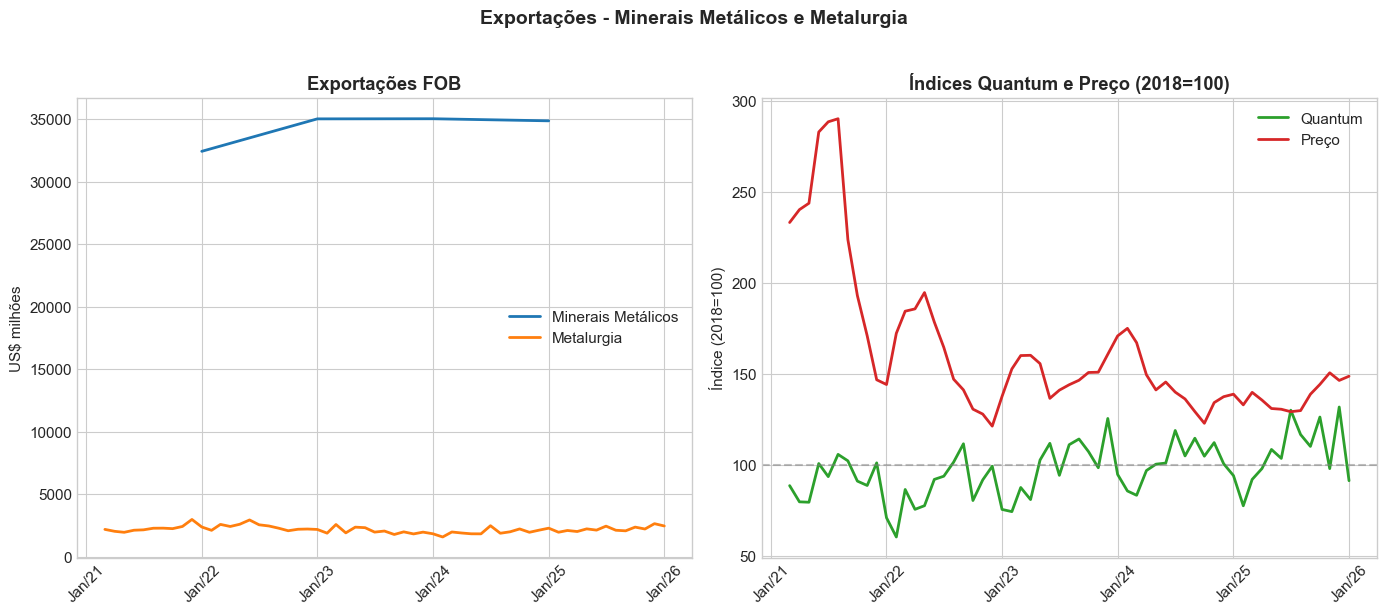

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Valores FOB
ax = axes[0]
for col, label, color in [
    ('export_minerais_metalicos_fob', 'Minerais Metálicos', '#1f77b4'),
    ('export_metalurgia_fob', 'Metalurgia', '#ff7f0e'),
]:
    s = monthly[col].dropna()
    ax.plot(s.index, s, label=label, color=color, linewidth=2)
ax.set_title('Exportações FOB', fontweight='bold')
ax.set_ylabel('US$ milhões')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

# Índices de quantum e preço
ax = axes[1]
for col, label, color in [
    ('export_minerais_metalicos_quantum', 'Quantum', '#2ca02c'),
    ('export_minerais_metalicos_preco', 'Preço', '#d62728'),
]:
    s = monthly[col].dropna()
    ax.plot(s.index, s, label=label, color=color, linewidth=2)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Índices Quantum e Preço (2018=100)', fontweight='bold')
ax.set_ylabel('Índice (2018=100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

fig.suptitle('Exportações - Minerais Metálicos e Metalurgia', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Indicadores Industriais CNI
Utilização da capacidade instalada, emprego e faturamento real da indústria.

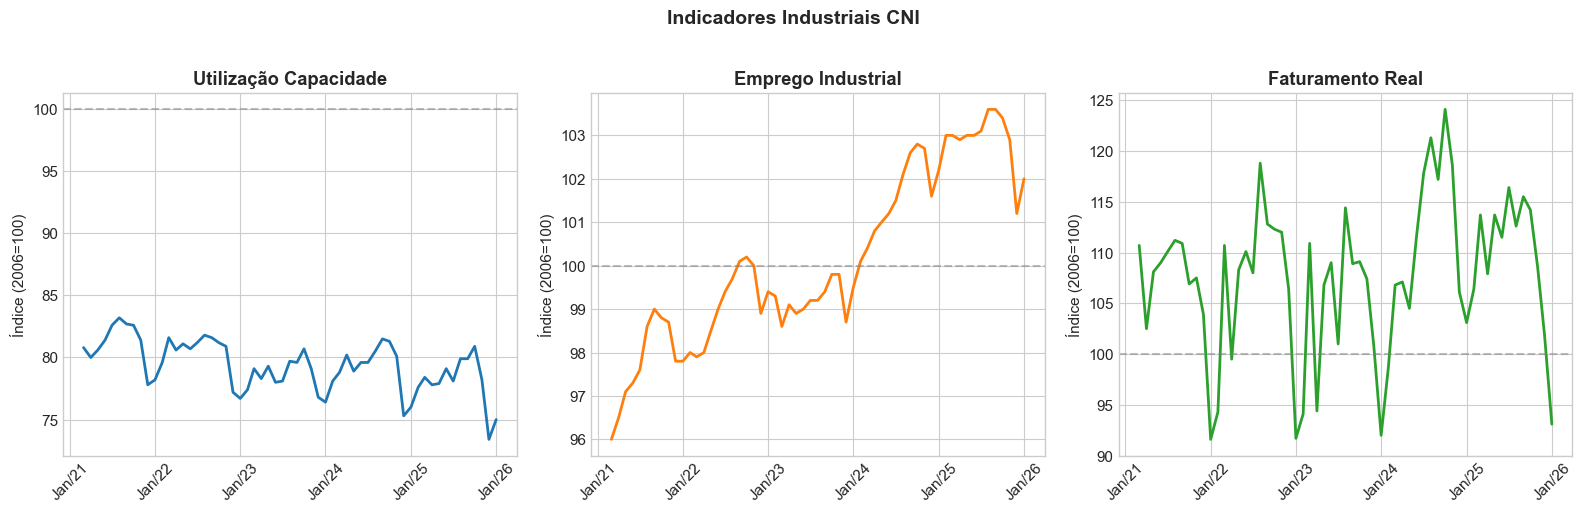

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

indicators = [
    ('utilizacao_capacidade_industrial', 'Utilização Capacidade', '#1f77b4'),
    ('emprego_industrial', 'Emprego Industrial', '#ff7f0e'),
    ('faturamento_real_industrial', 'Faturamento Real', '#2ca02c'),
]

for ax, (col, title, color) in zip(axes, indicators):
    s = monthly[col].dropna()
    ax.plot(s.index, s, color=color, linewidth=2)
    ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Índice (2006=100)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Indicadores Industriais CNI', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Dashboard - Visão Geral IPEADATA

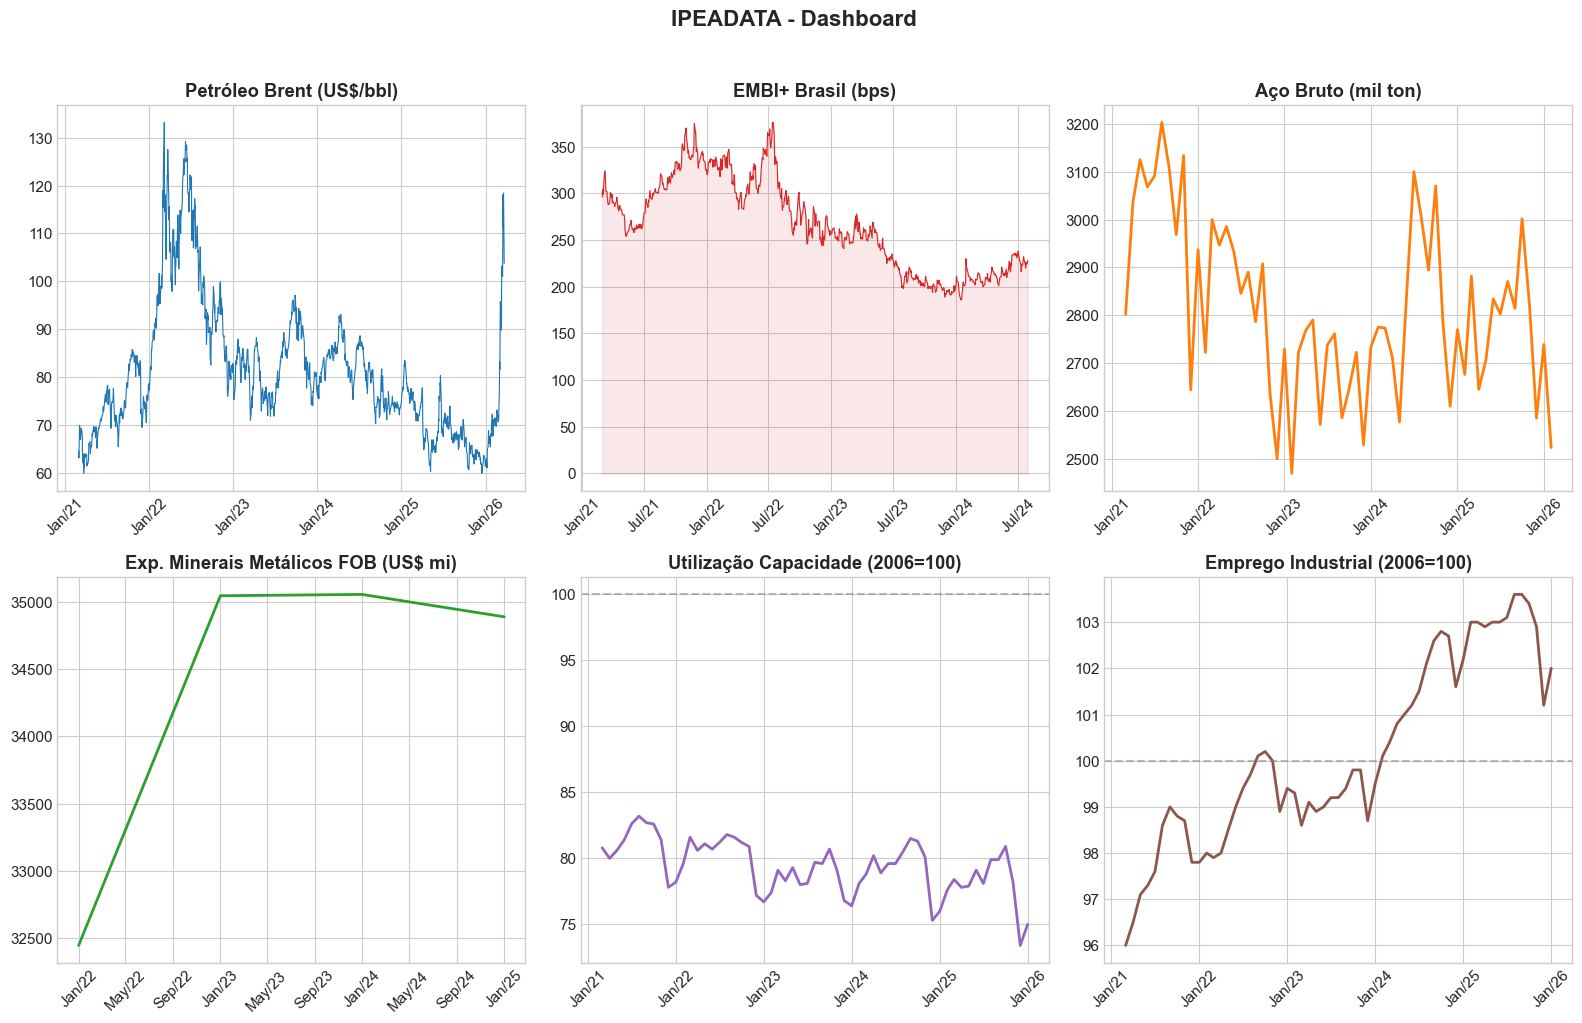

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Petróleo Brent
ax = axes[0, 0]
s = daily['preco_petroleo_brent'].dropna()
ax.plot(s.index, s, color='#1f77b4', linewidth=0.8)
ax.set_title('Petróleo Brent (US$/bbl)', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

# EMBI+ Risco-País
ax = axes[0, 1]
s = daily['embi_brasil'].dropna()
ax.plot(s.index, s, color='#d62728', linewidth=0.8)
ax.fill_between(s.index, s, alpha=0.1, color='#d62728')
ax.set_title('EMBI+ Brasil (bps)', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

# Aço Bruto
ax = axes[0, 2]
s = monthly['producao_aco_bruto'].dropna()
ax.plot(s.index, s, color='#ff7f0e', linewidth=2)
ax.set_title('Aço Bruto (mil ton)', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

# Exportações FOB
ax = axes[1, 0]
s = monthly['export_minerais_metalicos_fob'].dropna()
ax.plot(s.index, s, color='#2ca02c', linewidth=2)
ax.set_title('Exp. Minerais Metálicos FOB (US$ mi)', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

# Capacidade Industrial
ax = axes[1, 1]
s = monthly['utilizacao_capacidade_industrial'].dropna()
ax.plot(s.index, s, color='#9467bd', linewidth=2)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Utilização Capacidade (2006=100)', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

# Emprego Industrial
ax = axes[1, 2]
s = monthly['emprego_industrial'].dropna()
ax.plot(s.index, s, color='#8c564b', linewidth=2)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Emprego Industrial (2006=100)', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

fig.suptitle('IPEADATA - Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()